# FloodNet — Street Flooding Events Exploration

Flood events measured by [FloodNet](https://www.floodnet.nyc/) depth sensors across NYC (published 2026-06-24).

Each row is **one flood event** detected by one sensor: when it started/ended, how deep it got, how long it lasted, plus a full depth time series. The sensor name is prefixed with a borough code (`Q`, `BX`, `BK`, `M`, `SI`).

In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (10, 4)

# Raw CSVs live in the repo's data/ folder (gitignored). Resolve whether the
# notebook kernel runs from the repo root or from notebooks/.
DATA = "data" if os.path.isdir("data") else "../data"
CSV = f"{DATA}/FloodNet__Street_Flooding_Events_Measured_by_FloodNet_Sensors_20260624.csv"

In [16]:
# The last two columns are long JSON-ish arrays (per-event depth time series).
# Load everything as str first, then clean the numeric/date columns we care about.
df = pd.read_csv(CSV, dtype=str, keep_default_na=True, na_values=[""])
print(df.shape)
df.head()

(2448, 13)


,Sensor Name,Sensor ID,Flood Start Datetime (GMT),Flood End Datetime (GMT),Maximum Flood Depth (inches),Time to Maximum Flood Depth (minutes),Time to Drain From Peak (minutes),Total Duration (minutes),Duration of Flooding Greater Than 4 Inches (minutes),Duration of Flooding Greater Than 12 Inches (minutes),Duration of Flooding Greater Than 24 Inches (minutes),Time Series Depth Values (inches),Time Series Depth Timestamps (seconds)
0,Q - Beach 84 St,Q-beach-84-st-0me680,10/30/2023 12:00:39 PM,10/30/2023 04:38:19 PM,17.72,133.86,143.81,277.66,211.41,103.60,0.00,"[0.00, 0.87, 1.02, 1.38, 1.93, 2.64, 2.80, 3.1...","[0, 1008, 1134, 1512, 1826, 2079, 2142, 2206, ..."
1,BX - 1st St/Avenue A,BX-1st-st-avenue-a-1zby90,04/26/2025 11:17:20 PM,04/27/2025 11:55:34 AM,6.18,27.95,730.29,758.24,132.81,0.00,0.00,"[0.00, 0.71, 1.38, 1.38, 1.38, 1.38, 3.35, 4.6...","[0, 64, 129, 132, 196, 260, 324, 389, 453, 517..."
2,Q - Beach 35 St/Beach Channel Dr,Q-beach-35-st-beach-channel-dr-1oeug0,02/09/2024 11:41:01 AM,02/09/2024 01:20:57 PM,5.31,54.51,45.43,99.94,45.09,0.00,0.00,"[0.00, 0.43, 0.63, 0.71, 0.94, 1.18, 1.26, 1.5...","[0, 68, 136, 204, 273, 341, 409, 477, 545, 613..."
3,BX - Tibbett Ave/W 234th St,BX-w-234th-st-tibbett-ave-2cakho,08/20/2025 09:05:19 PM,08/21/2025 12:46:19 AM,1.18,80.00,141.00,221.00,0.00,0.00,0.00,"[0.00, 0.43, 0.47, 0.47, 0.51, 0.51, 0.51, 0.5...","[0, 60, 120, 180, 240, 300, 360, 420, 480, 540..."
4,Q - Davenport Ct 1,Q-davenport-ct-1-07zks0,01/10/2024 12:39:25 AM,01/10/2024 02:30:40 AM,2.09,59.82,51.43,111.25,0.00,0.00,0.00,"[0.00, 0.47, 0.47, 0.43, 0.43, 0.00, 0.00, 0.0...","[0, 63, 127, 189, 252, 315, 379, 505, 568, 631..."


In [17]:
# Clean types: parse datetimes (GMT) and cast the metric columns to float.
# The numeric columns use thousands separators (e.g. "1,647.58"), so strip commas first.
df["Flood Start Datetime (GMT)"] = pd.to_datetime(df["Flood Start Datetime (GMT)"], errors="coerce")
df["Flood End Datetime (GMT)"] = pd.to_datetime(df["Flood End Datetime (GMT)"], errors="coerce")

metric_cols = [
    "Maximum Flood Depth (inches)",
    "Time to Maximum Flood Depth (minutes)",
    "Time to Drain From Peak (minutes)",
    "Total Duration (minutes)",
    "Duration of Flooding Greater Than 4 Inches (minutes)",
    "Duration of Flooding Greater Than 12 Inches (minutes)",
    "Duration of Flooding Greater Than 24 Inches (minutes)",
]
for c in metric_cols:
    df[c] = df[c].str.replace(",", "", regex=False).astype(float)

df.dtypes

C:\Users\david\AppData\Local\Temp\ipykernel_23392\4216105907.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Flood End Datetime (GMT)"] = pd.to_datetime(df["Flood End Datetime (GMT)"], errors="coerce")


Sensor Name                                                         str
Sensor ID                                                           str
Flood Start Datetime (GMT)                               datetime64[us]
Flood End Datetime (GMT)                                 datetime64[us]
Maximum Flood Depth (inches)                                    float64
Time to Maximum Flood Depth (minutes)                           float64
Time to Drain From Peak (minutes)                               float64
Total Duration (minutes)                                        float64
Duration of Flooding Greater Than 4 Inches (minutes)            float64
Duration of Flooding Greater Than 12 Inches (minutes)           float64
Duration of Flooding Greater Than 24 Inches (minutes)           float64
Time Series Depth Values (inches)                                   str
Time Series Depth Timestamps (seconds)                              str
dtype: object

In [18]:
# Derive a borough from the sensor-name prefix and some convenient time fields.
BOROUGH = {"BX": "Bronx", "BK": "Brooklyn", "M": "Manhattan", "Q": "Queens", "SI": "Staten Island"}
df["Borough Code"] = df["Sensor Name"].str.split(" - ", n=1).str[0].str.strip()
df["Borough"] = df["Borough Code"].map(BOROUGH).fillna("Unknown")

df["Year"] = df["Flood Start Datetime (GMT)"].dt.year
df["Month"] = df["Flood Start Datetime (GMT)"].dt.to_period("M").astype(str)
df["Hour"] = df["Flood Start Datetime (GMT)"].dt.hour

df[["Sensor Name", "Borough", "Year", "Month", "Hour"]].head()

,Sensor Name,Borough,Year,Month,Hour
0,Q - Beach 84 St,Queens,2023,2023-10,12
1,BX - 1st St/Avenue A,Bronx,2025,2025-04,23
2,Q - Beach 35 St/Beach Channel Dr,Queens,2024,2024-02,11
3,BX - Tibbett Ave/W 234th St,Bronx,2025,2025-08,21
4,Q - Davenport Ct 1,Queens,2024,2024-01,0


In [19]:
# Overview: dtype, non-null count, unique values per column (skip the bulky time-series cols).
cols = [c for c in df.columns if not c.startswith("Time Series")]
pd.DataFrame({
    "dtype": df[cols].dtypes,
    "non_null": df[cols].notna().sum(),
    "nunique": df[cols].nunique(dropna=True),
})

,dtype,non_null,nunique
Sensor Name,str,2448,258
Sensor ID,str,2448,260
Flood Start Datetime (GMT),datetime64[us],2448,2445
Flood End Datetime (GMT),datetime64[us],2448,2445
Maximum Flood Depth (inches),float64,2448,421
Time to Maximum Flood Depth (minutes),float64,2448,1611
Time to Drain From Peak (minutes),float64,2447,1727
Total Duration (minutes),float64,2448,1905
Duration of Flooding Greater Than 4 Inches (minutes),float64,2448,1094
Duration of Flooding Greater Than 12 Inches (minutes),float64,2448,195


In [20]:
# Summary stats on the core flood metrics.
df[metric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Maximum Flood Depth (inches),2448.0,5.105404,5.052436,0.43,1.77,3.580,6.6100,46.14
Time to Maximum Flood Depth (minutes),2448.0,639.805760,28656.456563,1.00,17.00,40.955,83.1975,1417896.50
Time to Drain From Peak (minutes),2447.0,100.362501,169.727640,1.00,29.43,56.700,109.5250,2782.15
Total Duration (minutes),2448.0,161.252876,226.909617,5.00,52.62,119.815,193.7725,4542.91
Duration of Flooding Greater Than 4 Inches (minutes),2448.0,47.306422,101.647251,0.00,0.00,0.000,74.1325,3342.65
Duration of Flooding Greater Than 12 Inches (minutes),2448.0,7.224375,34.675571,0.00,0.00,0.000,0.0000,516.27
Duration of Flooding Greater Than 24 Inches (minutes),2448.0,0.721977,9.206697,0.00,0.00,0.000,0.0000,245.30


In [21]:
# Coverage window and event counts.
print("Events:", len(df))
print("Unique sensors:", df["Sensor ID"].nunique())
print("Date range:", df["Flood Start Datetime (GMT)"].min(), "->", df["Flood Start Datetime (GMT)"].max())
print("\nEvents by borough:")
print(df["Borough"].value_counts(dropna=False))

Events: 2448
Unique sensors: 260
Date range: 2020-11-16 01:41:17 -> 2026-06-07 17:51:59

Events by borough:
Borough
Queens           1447
Bronx             431
Brooklyn          347
Staten Island     174
Manhattan          49
Name: count, dtype: int64


## Visuals

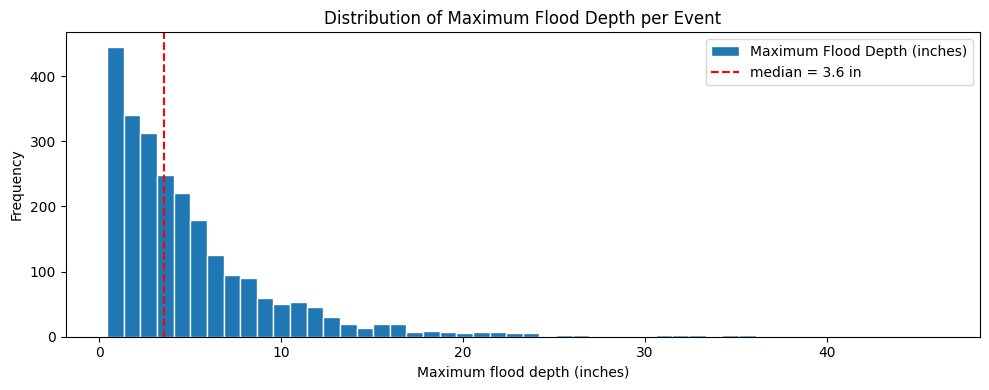

In [22]:
# Distribution of maximum flood depth.
ax = df["Maximum Flood Depth (inches)"].plot(kind="hist", bins=50, edgecolor="white")
ax.axvline(df["Maximum Flood Depth (inches)"].median(), color="red", linestyle="--",
           label=f"median = {df['Maximum Flood Depth (inches)'].median():.1f} in")
ax.set_title("Distribution of Maximum Flood Depth per Event")
ax.set_xlabel("Maximum flood depth (inches)")
ax.legend()
plt.tight_layout()
plt.show()

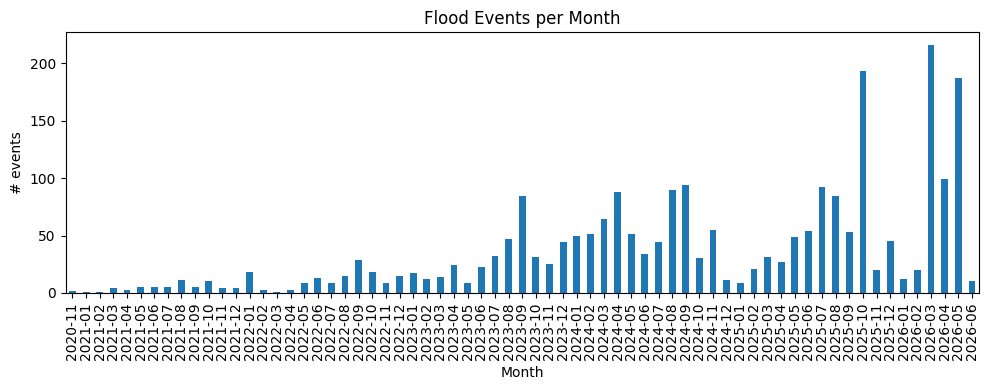

In [23]:
# Flood events per month.
monthly = df.dropna(subset=["Flood Start Datetime (GMT)"]).groupby("Month").size()
ax = monthly.plot(kind="bar", title="Flood Events per Month")
ax.set_ylabel("# events")
ax.set_xlabel("Month")
plt.tight_layout()
plt.show()

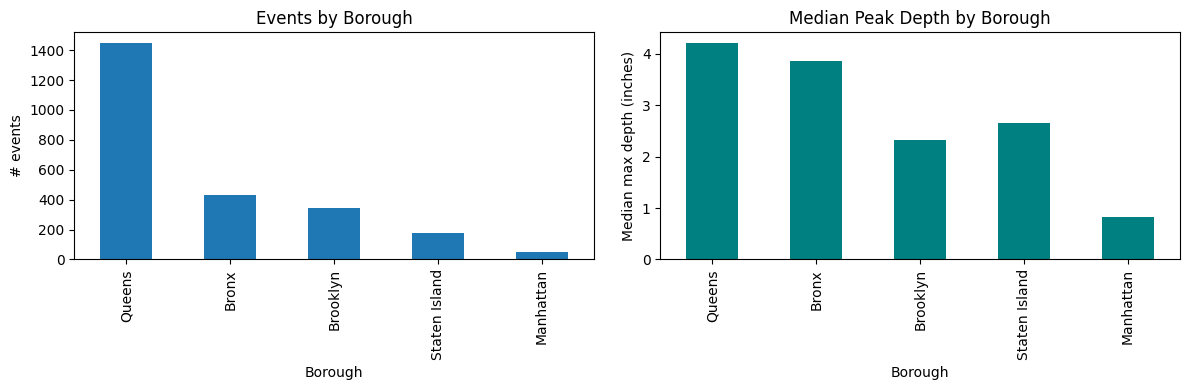

In [24]:
# Events by borough, and median peak depth within each borough.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
by_boro = df["Borough"].value_counts()
by_boro.plot(kind="bar", ax=axes[0], title="Events by Borough")
axes[0].set_ylabel("# events")

(df.groupby("Borough")["Maximum Flood Depth (inches)"].median()
   .reindex(by_boro.index)
   .plot(kind="bar", ax=axes[1], color="teal", title="Median Peak Depth by Borough"))
axes[1].set_ylabel("Median max depth (inches)")
plt.tight_layout()
plt.show()

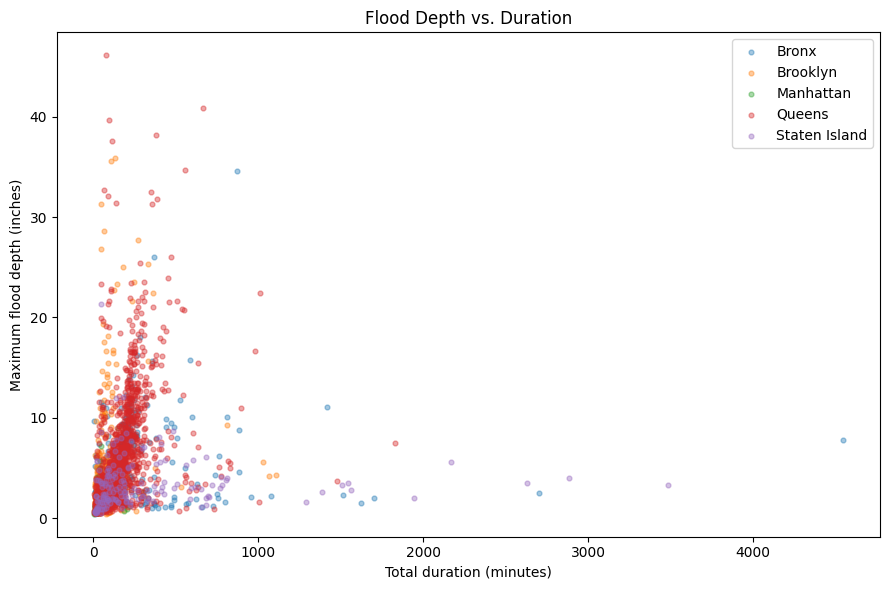

In [25]:
# Depth vs. duration: do deeper floods last longer? Color by borough.
fig, ax = plt.subplots(figsize=(9, 6))
for boro, g in df.groupby("Borough"):
    ax.scatter(g["Total Duration (minutes)"], g["Maximum Flood Depth (inches)"],
               s=12, alpha=0.4, label=boro)
ax.set_xlabel("Total duration (minutes)")
ax.set_ylabel("Maximum flood depth (inches)")
ax.set_title("Flood Depth vs. Duration")
ax.legend()
plt.tight_layout()
plt.show()

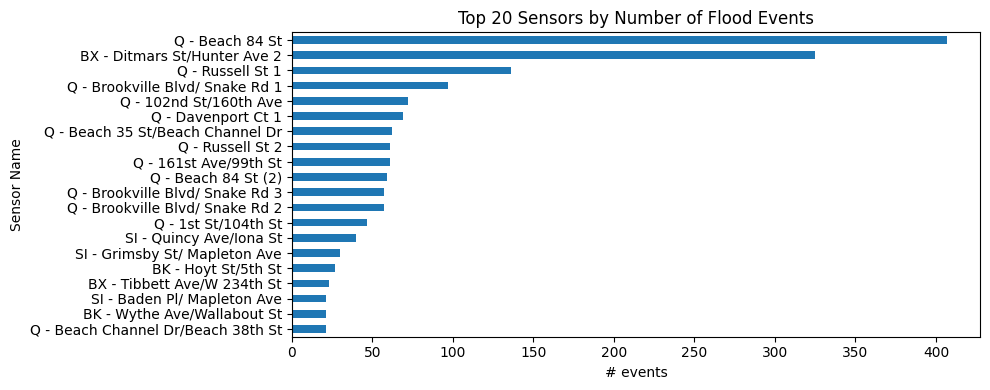

,events,median_depth,max_depth
Sensor Name,,,
Q - Beach 84 St,407,4.720,38.19
BX - Ditmars St/Hunter Ave 2,325,4.530,34.65
Q - Russell St 1,136,5.510,31.34
Q - Brookville Blvd/ Snake Rd 1,97,3.740,19.76
Q - 102nd St/160th Ave,72,4.075,21.69
Q - Davenport Ct 1,69,6.890,40.87
Q - Beach 35 St/Beach Channel Dr,62,4.410,11.77
Q - Russell St 2,61,5.510,31.77
Q - 161st Ave/99th St,61,3.580,20.08


In [26]:
# Sensors that flood most often.
top_sensors = (df.groupby("Sensor Name")
                 .agg(events=("Sensor ID", "size"),
                      median_depth=("Maximum Flood Depth (inches)", "median"),
                      max_depth=("Maximum Flood Depth (inches)", "max"))
                 .sort_values("events", ascending=False)
                 .head(20))
ax = top_sensors["events"][::-1].plot(kind="barh", title="Top 20 Sensors by Number of Flood Events")
ax.set_xlabel("# events")
plt.tight_layout()
plt.show()
top_sensors

In [27]:
# Worst single events by peak depth.
(df[["Sensor Name", "Borough", "Flood Start Datetime (GMT)",
     "Maximum Flood Depth (inches)", "Total Duration (minutes)"]]
   .sort_values("Maximum Flood Depth (inches)", ascending=False)
   .head(15)
   .reset_index(drop=True))

,Sensor Name,Borough,Flood Start Datetime (GMT),Maximum Flood Depth (inches),Total Duration (minutes)
0,Q - 183rd St/90th Ave,Queens,2026-05-20 23:21:49,46.14,74.00
1,Q - Davenport Ct 1,Queens,2022-12-23 10:24:23,40.87,664.96
2,Q - Liberty Ave/ 183rd St,Queens,2026-05-20 23:24:32,39.65,96.01
3,Q - Beach 84 St,Queens,2022-12-23 10:00:52,38.19,378.31
4,Q - Woodhull Ave/ 193rd St,Queens,2026-05-20 23:15:23,37.56,114.00
5,BK - Carroll St/4th Av,Brooklyn,2023-09-29 11:53:39,35.94,129.18
6,BK - Carroll St/4th Av,Brooklyn,2021-09-02 01:27:16,35.59,104.17
7,Q - Davenport Ct 1,Queens,2024-01-13 13:05:35,34.69,553.46
8,BX - Ditmars St/Hunter Ave 2,Bronx,2024-04-03 16:04:19,34.65,870.27
9,Q - 204th St/ 100th Ave,Queens,2026-05-20 23:27:49,32.72,65.00


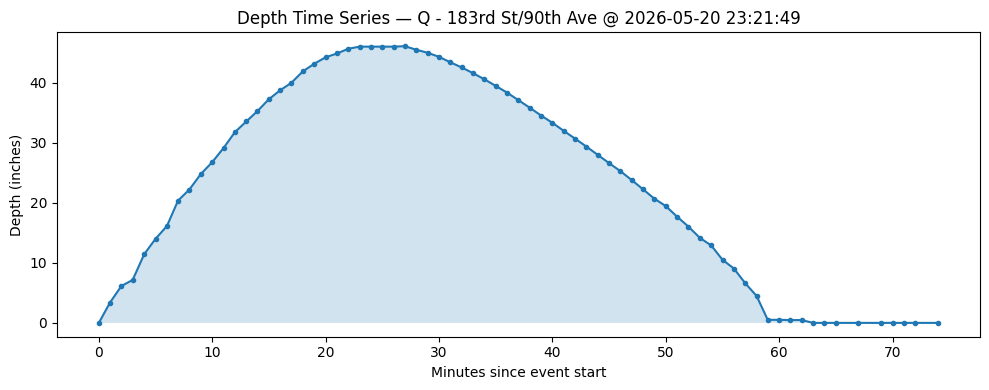

In [28]:
# Plot the depth time series of a single event (the deepest one) from the stored arrays.
import json

row = df.loc[df["Maximum Flood Depth (inches)"].idxmax()]
depths = json.loads(row["Time Series Depth Values (inches)"])
secs = json.loads(row["Time Series Depth Timestamps (seconds)"])
mins = [s / 60 for s in secs]

ax = plt.subplots(figsize=(10, 4))[1]
ax.plot(mins, depths, marker=".")
ax.fill_between(mins, depths, alpha=0.2)
ax.set_title(f"Depth Time Series — {row['Sensor Name']} @ {row['Flood Start Datetime (GMT)']}")
ax.set_xlabel("Minutes since event start")
ax.set_ylabel("Depth (inches)")
plt.tight_layout()
plt.show()

## Mapping the most recent flooding event

The street-flooding file has no coordinates, but the **Sensor Deployment Metadata** file does. We join on `Sensor ID` to get `Latitude`/`Longitude`, then map the sensors that flooded during the most recent flooding episode — the **2026-06-07** storm, which tripped sensors across Queens, the Bronx, Manhattan and Staten Island.

Two maps below: an **interactive** folium map (real street basemap, click markers for detail) and a **static** matplotlib version that also shows all sensor locations for citywide context.

In [29]:
# Join sensor coordinates from the deployment-metadata file.
META = f"{DATA}/FloodNet__Sensor_Deployment_Metadata_20260624.csv"
meta = pd.read_csv(META, dtype=str)
meta["Latitude"] = meta["Latitude"].astype(float)
meta["Longitude"] = meta["Longitude"].astype(float)

df = df.merge(
    meta[["Sensor ID", "Latitude", "Longitude", "Street Name"]],
    on="Sensor ID", how="left",
)
print("events missing coordinates:", df["Latitude"].isna().sum(), "of", len(df))

# "Most recent flooding event" = the latest calendar day on which any sensor flooded.
df["Flood Day"] = df["Flood Start Datetime (GMT)"].dt.date
latest_day = df["Flood Day"].max()

event = (df[df["Flood Day"] == latest_day]
           .groupby(["Sensor Name", "Borough", "Latitude", "Longitude"], as_index=False)
           .agg(events=("Sensor ID", "size"),
                max_depth=("Maximum Flood Depth (inches)", "max"),
                total_minutes=("Total Duration (minutes)", "sum")))
print(f"\nMost recent flooding episode: {latest_day} - "
      f"{event['events'].sum()} events across {len(event)} sensors")
event.sort_values("max_depth", ascending=False).reset_index(drop=True)

events missing coordinates: 0 of 2448

Most recent flooding episode: 2026-06-07 - 7 events across 6 sensors


,Sensor Name,Borough,Latitude,Longitude,events,max_depth,total_minutes
0,SI - Quincy Ave/Iona St,Staten Island,40.576402,-74.084275,1,2.56,182.01
1,Q - Linden Pl/ 28th Ave,Queens,40.772019,-73.833792,1,1.30,73.00
2,BX - Tibbett Ave/W 234th St,Bronx,40.883260,-73.905850,1,1.14,102.00
3,BX - Ditmars St/Hunter Ave 2,Bronx,40.849297,-73.789528,2,1.10,77.99
4,Q - Davenport Ct 1,Queens,40.653387,-73.830559,1,0.91,92.44
5,M - 126th St/7th Av,Manhattan,40.809830,-73.948101,1,0.75,188.00


In [30]:
# Interactive map on a real street basemap (folium / Leaflet + OpenStreetMap tiles).
# Circle radius + color encode how deep each sensor flooded. Click a marker for details.
import folium
import branca.colormap as cm

center = [event["Latitude"].mean(), event["Longitude"].mean()]
fmap = folium.Map(location=center, zoom_start=11, tiles="cartodbpositron")

cmap = cm.linear.Blues_09.scale(event["max_depth"].min(), event["max_depth"].max())
cmap.caption = "Maximum flood depth (inches)"
fmap.add_child(cmap)

for _, r in event.iterrows():
    folium.CircleMarker(
        location=[r["Latitude"], r["Longitude"]],
        radius=6 + r["max_depth"] * 3,
        color="navy", weight=1, fill=True,
        fill_color=cmap(r["max_depth"]), fill_opacity=0.85,
        popup=folium.Popup(
            f"<b>{r['Sensor Name']}</b><br>{r['Borough']}<br>"
            f"Max depth: {r['max_depth']:.2f} in<br>"
            f"Events: {r['events']}<br>"
            f"Total flooded: {r['total_minutes']:.0f} min",
            max_width=250),
        tooltip=f"{r['Sensor Name']} - {r['max_depth']:.1f} in",
    ).add_to(fmap)

fmap

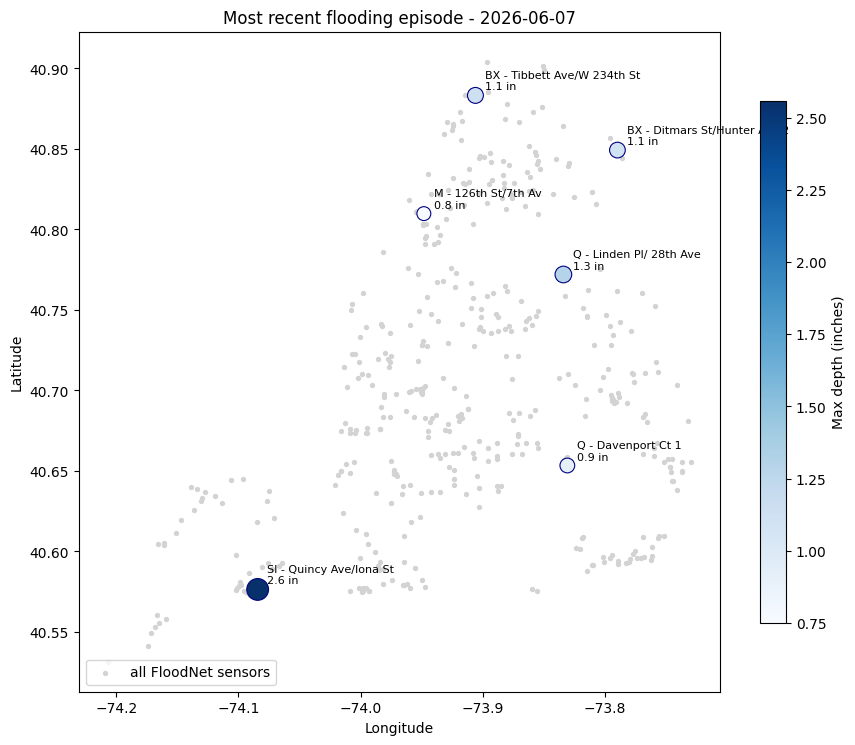

In [31]:
# Static map fallback (no basemap tiles): sensor positions labeled, sized by depth.
# Plotted against all sensor locations (light grey) for citywide context.
fig, ax = plt.subplots(figsize=(9, 9))
ax.scatter(meta["Longitude"], meta["Latitude"], s=8, color="lightgrey",
           label="all FloodNet sensors", zorder=1)
sc = ax.scatter(event["Longitude"], event["Latitude"],
                s=event["max_depth"] * 80 + 40, c=event["max_depth"],
                cmap="Blues", edgecolor="navy", linewidth=0.8, zorder=3)
for _, r in event.iterrows():
    ax.annotate(f"{r['Sensor Name']}\n{r['max_depth']:.1f} in",
                (r["Longitude"], r["Latitude"]),
                textcoords="offset points", xytext=(7, 4), fontsize=8)

ax.set_aspect(1 / np.cos(np.radians(40.7)))  # approx equal-distance at NYC latitude
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title(f"Most recent flooding episode - {latest_day}")
fig.colorbar(sc, ax=ax, shrink=0.6, label="Max depth (inches)")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

## Scratch
Free space below for your own slicing.

Handy columns: `Time to Maximum Flood Depth (minutes)`, `Time to Drain From Peak (minutes)`, `Duration of Flooding Greater Than 12 Inches (minutes)`, `Hour` (GMT). The two `Time Series ...` columns are JSON arrays — `json.loads` them per row as shown above.